Notebook to test the computation of the CRPS of given events, with respect to the climatology, but taking in this climatology only events which are in the same period of the year.

In [1]:
%load_ext autoreload
%autoreload 2

import xarray as xr
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from CRPS import comp_CRPS_clim

# Load data

In [2]:
data_folder = 'data/'

# load
allpcs = xr.open_dataset(data_folder + 'pcs.nc')['pseudo_pcs']
eofs = xr.open_dataset(data_folder + 'eofs.nc')['eofs']
pourc_EOF = xr.open_dataset(data_folder + 'pourc_eofs.nc')['variance_fractions']

# normalize pcs but keep relative variances
pcs_norm = allpcs / (allpcs.sel(mode=0)).std(dim='time')

# Dataset length
L = len(pcs_norm)

# Compute CRPS wrt clim

In [3]:
horizon = 3 # in days
subsampling = 7 # in days

In [13]:
dh = 2*horizon
y = pcs_norm[dh:]
dataset_x = pcs_norm[:-2*10,] # here I need to use the highest value for the horizon, in order for dataset_x to be compatible with the section where dependence of the CRPS on the horizon
ind_tar = np.arange(len(dataset_x))[::2*subsampling]

In [24]:
targets = dataset_x[ind_tar].rename({'time': 'target_time'})
CRPS_clim_30 = comp_CRPS_clim(y, targets, 30, n_samples_pairs = 1000, n_ref = 1000)
CRPS_clim_inf = comp_CRPS_clim(y, targets, np.inf, n_samples_pairs = 1000, n_ref = 1000)

100%|███████████████████████████████████████| 2336/2336 [00:33<00:00, 70.69it/s]


# Compute CRPS using Paul's functions

In [19]:
from analogues_functions import compute_CRPSclim_fast
ind_tar_y = np.argmax((targets.target_time == y.time).data, axis = 1) # indices of the targets in y
CRPS_clim_paul = compute_CRPSclim_fast(y.data, ind_tar=ind_tar_y, n_sample_pairs=1000, n_ref=1000)

# Check and compare results

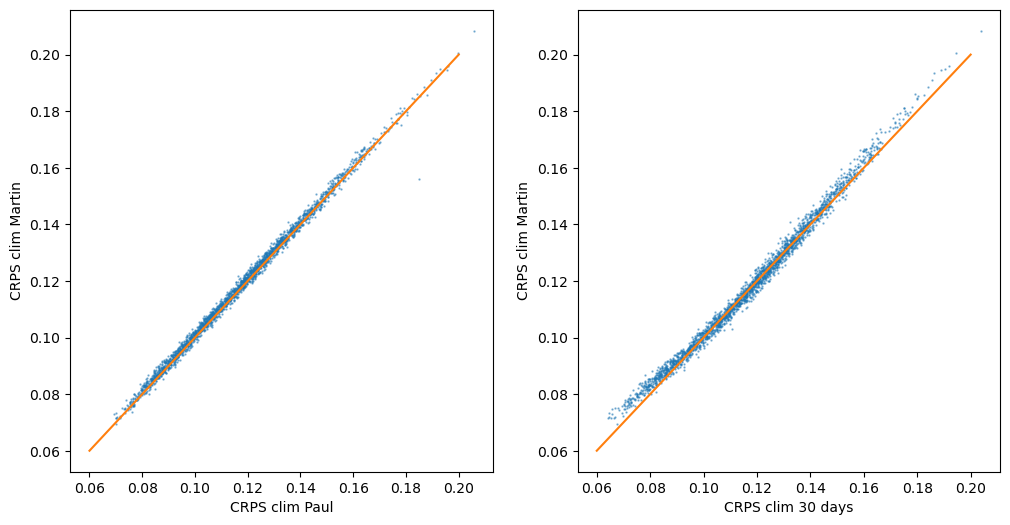

In [25]:
fig, axs = plt.subplots(1, 2, figsize = (12, 6))

axs[0].scatter(CRPS_clim_paul, CRPS_clim_inf, s = 0.5, alpha = 0.5)
axs[0].set_xlabel('CRPS clim Paul')
axs[0].set_ylabel('CRPS clim Martin')
axs[0].plot([0.06, 0.2], [0.06, 0.2], c = 'C1')

axs[1].scatter(CRPS_clim_30, CRPS_clim_inf, s = 0.5, alpha = 0.5)
axs[1].set_xlabel('CRPS clim 30 days')
axs[1].set_ylabel('CRPS clim Martin')
axs[1].plot([0.06, 0.2], [0.06, 0.2], c = 'C1')

(array([  1.,   0.,   0.,   1.,   3.,  13.,  11.,  24.,  47.,  58., 119.,
        135., 190., 205., 229., 241., 248., 177., 150., 137.,  98.,  64.,
         71.,  35.,  30.,  19.,  11.,  11.,   5.,   3.]),
 array([-7.65933096e-03, -7.11042384e-03, -6.56151672e-03, -6.01260960e-03,
        -5.46370248e-03, -4.91479536e-03, -4.36588824e-03, -3.81698112e-03,
        -3.26807400e-03, -2.71916687e-03, -2.17025975e-03, -1.62135263e-03,
        -1.07244551e-03, -5.23538391e-04,  2.53687302e-05,  5.74275851e-04,
         1.12318297e-03,  1.67209009e-03,  2.22099721e-03,  2.76990434e-03,
         3.31881146e-03,  3.86771858e-03,  4.41662570e-03,  4.96553282e-03,
         5.51443994e-03,  6.06334706e-03,  6.61225418e-03,  7.16116130e-03,
         7.71006842e-03,  8.25897555e-03,  8.80788267e-03]),
 <BarContainer object of 30 artists>)

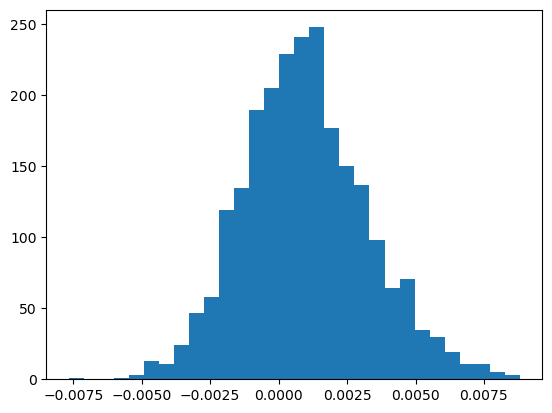

In [26]:
plt.hist(CRPS_clim_inf - CRPS_clim_30, bins = 30)

# Check the dependence of the CRPS on the horizon

In [37]:
from analogues_functions import (find_analogues, loo_procedure, separate_trajectories, 
compute_diffs, compute_mae_mad, compute_CRPSana, compute_CRPSclim, compute_mae_monte_carlo, compute_CRPSclim_fast)

In [38]:
# Choose maximum number of analogues
Kmax = 500
# Set subsampling in catalogue to avoid taking neighbours that are time-correlated
step_subsampling_catalogue = 2*7

# find analogues
dist, ind = find_analogues(pcs_norm, ind_tar=ind_tar,
                           K=Kmax, step_subsampling_catalogue = step_subsampling_catalogue, )

In [39]:
CRPS_ana = {}

horizons = [1, 2, 3, 5, 10]

for h in tqdm(horizons):
    dh = 2*h
    dataset_y = np.array(pcs_norm[dh:,])
    dataset_x = np.array(pcs_norm[:-dh,])
    step_subsampling_catalogue = 2*4
    CRPS_ana[str(h)] = compute_CRPSana(dataset_x, dataset_y, ind_tar=ind_tar, loo=True, dt_loo = 2*30, K=50,
                               step_subsampling_catalogue=step_subsampling_catalogue, n_jobs=14)

100%|█████████████████████████████████████████████| 5/5 [00:06<00:00,  1.39s/it]


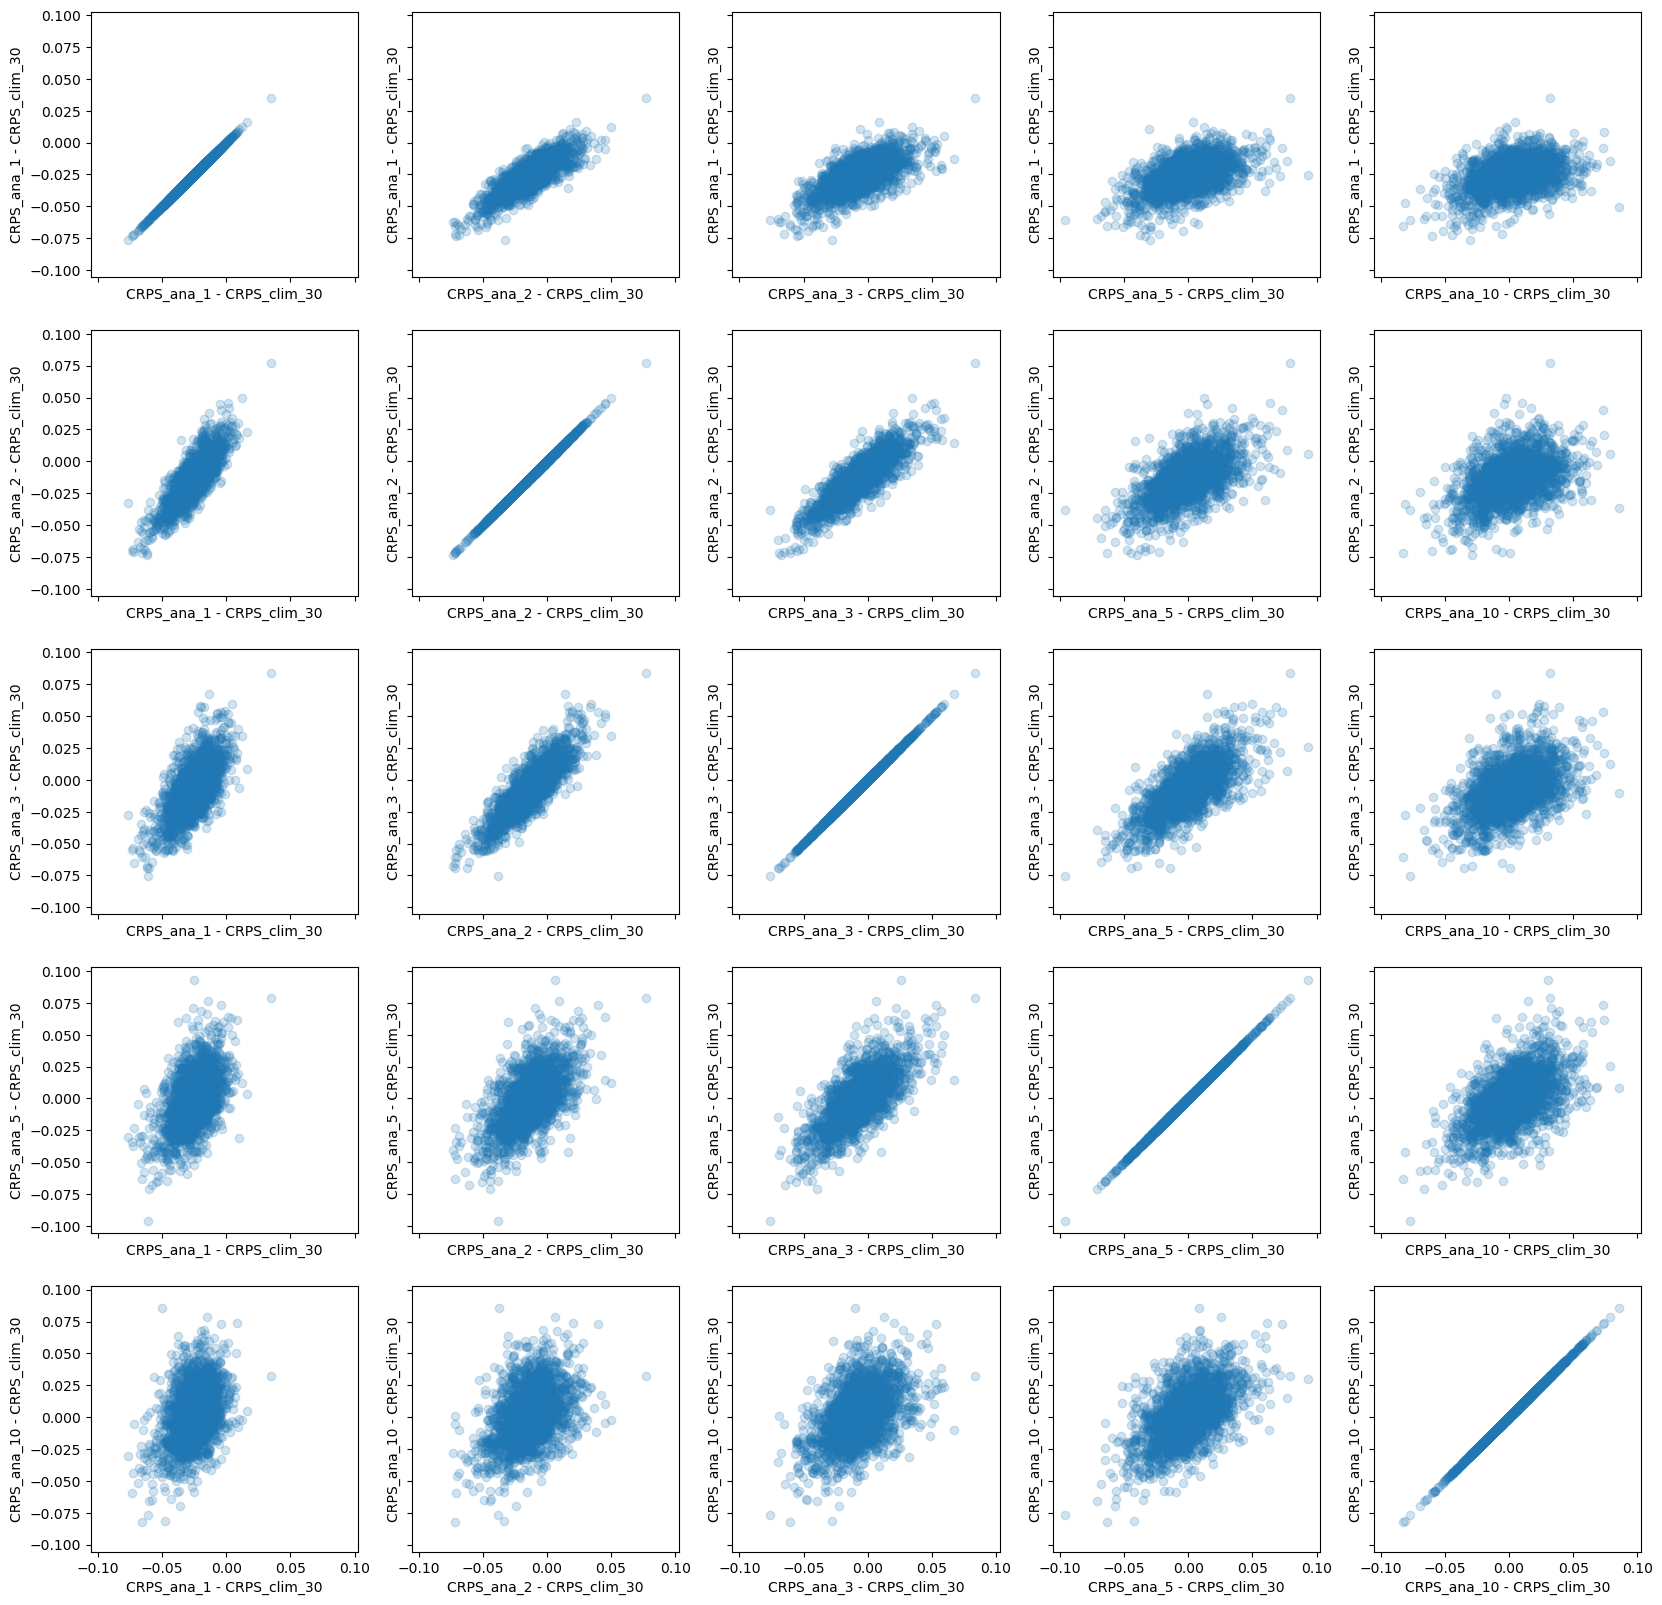

In [40]:
fig, axs = plt.subplots(len(horizons), len(horizons), figsize = (20,20), sharex = True, sharey = True)

for i1, h1 in enumerate(horizons):
    for i2, h2 in enumerate(horizons):
        axs[i1, i2].scatter(CRPS_ana[str(h2)] - CRPS_clim_30, CRPS_ana[str(h1)] - CRPS_clim_30, alpha = 0.2)
        axs[i1, i2].set_ylabel(f'CRPS_ana_{h1} - CRPS_clim_30')
        axs[i1, i2].set_xlabel(f'CRPS_ana_{h2} - CRPS_clim_30')

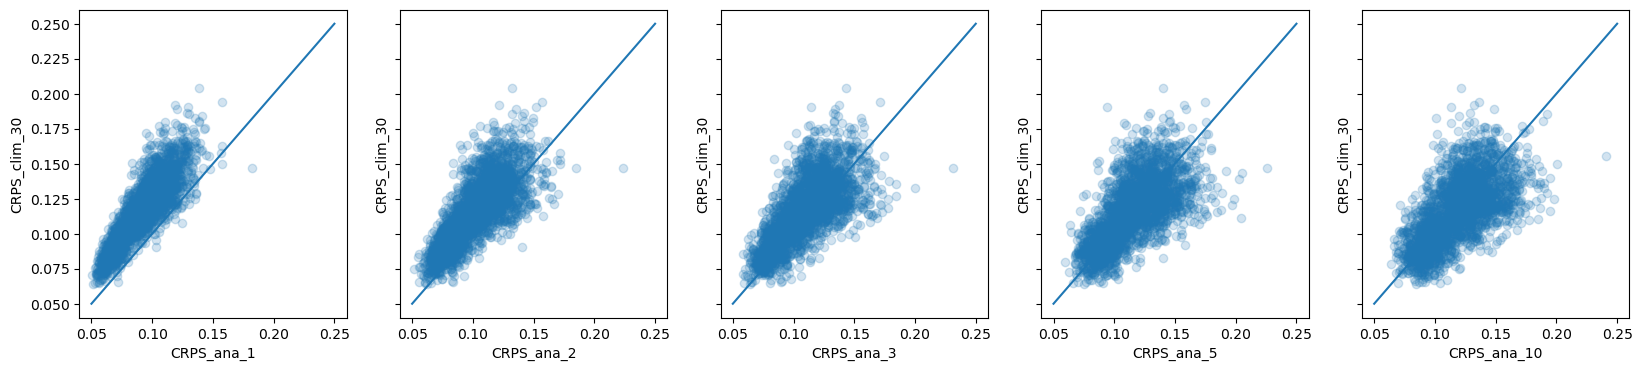

In [41]:
fig, axs = plt.subplots(1, len(horizons), sharey = True, sharex = True, figsize = (20, 4))

for i, h in enumerate(horizons):
    axs[i].scatter(CRPS_ana[str(h)], CRPS_clim_30, alpha = 0.2)
    axs[i].set_xlabel(f'CRPS_ana_{h}')
    axs[i].set_ylabel('CRPS_clim_30')
    axs[i].plot([0.05, 0.25], [0.05, 0.25])